<a href="https://colab.research.google.com/github/eshanth23/cs666student/blob/main/CS666_Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

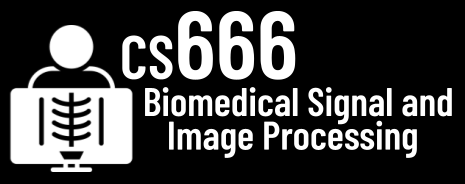
#Assignment 4

In [ ]:
# NAME: Eshanth Kumar Lal Das

In [ ]:
# In this assignment, we will create a Random Forest classifier to detect pneumonia and covid in xrays!

In [1]:
# load numpy and matplotlib
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [2]:
# we are using mahotas again, so lets install it!
!pip install mahotas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 10.5 MB/s eta 0:00:00


In [3]:
# our imports include sklearn this time
import mahotas as mh
import os
from sklearn.ensemble import RandomForestClassifier

**Task 1:** Download, extract, and load the data! [15 Points]

In [ ]:
# Please download this file: https://cs666.org/data/xray/ with the wget command!
# Note: Please use the forwarded dropbox link and change dl=0 to dl=1!
# This is a subset of the Kaggle Pneumonia + Covid Datasets!

In [ ]:
# Run this code to extract the zip file and to create
# the folder structure of normal/, pneumonia/, and covid/ images.
# Each folder contains the first images of the Kaggle datasets.
import zipfile
with zipfile.ZipFile('xray.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

NORMAL_DIR = 'normal/'
PNEUMONIA_DIR = 'pneumonia/'
COVID_DIR = 'covid/'

In [ ]:
# Here we load the first image from the normal dataset.
img = mh.imread(NORMAL_DIR + 'IM-0115-0001.jpeg')

In [ ]:
# TODO: Please display this image and print the dimensions!

In [ ]:
# TODO: YOUR CODE

In [6]:
!wget -O xray.zip "https://www.dropbox.com/s/2ca2889o2ql8n4e/xray.zip?dl=1"

--2026-04-20 21:34:59--  https://www.dropbox.com/s/2ca2889o2ql8n4e/xray.zip?dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.85.18, 2620:100:6030:18::a27d:5012
Connecting to www.dropbox.com (www.dropbox.com)|162.125.85.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/sso8jwvfhoxqarp4zd3fb/xray.zip?rlkey=rvjqu3yj6gmw3r7gmst4ke9fl&dl=1 [following]
--2026-04-20 21:34:59--  https://www.dropbox.com/scl/fi/sso8jwvfhoxqarp4zd3fb/xray.zip?rlkey=rvjqu3yj6gmw3r7gmst4ke9fl&dl=1
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://ucb4a0fefe4252efec71ca390ff0.dl.dropboxusercontent.com/cd/0/inline/C--9Km0wdcJJECfqBEbblIMr3nBaq6HSdelZO0UvgX06-khFzA5e9OWhMrRnuGw_3l7-aR99hxlbHnxU9beAl7DX6t5fFaPJmlTKqcHgy1NZUZKNn0jhPKTnr0WBJT5KHz4/file?dl=1# [following]
--2026-04-20 21:34:59--  https://ucb4a0fefe4252efec71ca390ff0.dl.dropboxusercontent.com/cd/0/inline/C--9Km0wdcJ

Image dimensions: (1858, 2090)


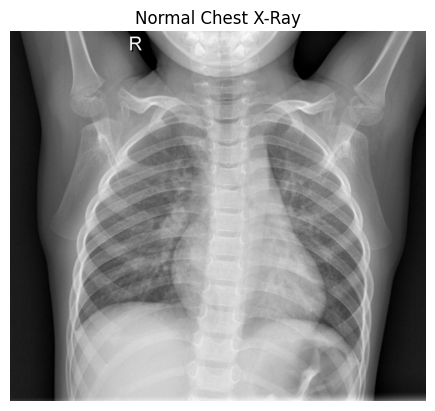

In [7]:
import zipfile
import mahotas as mh
import matplotlib.pyplot as plt

# Extract zip file
with zipfile.ZipFile('xray.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

NORMAL_DIR = 'normal/'
PNEUMONIA_DIR = 'pneumonia/'
COVID_DIR = 'covid/'

# Load the first image from normal dataset
img = mh.imread(NORMAL_DIR + 'IM-0115-0001.jpeg')

# Display image and print dimensions
print("Image dimensions:", img.shape)
plt.imshow(img, cmap='gray')
plt.title('Normal Chest X-Ray')
plt.axis('off')
plt.show()

**Task 2:** Let's do some data wrangling and more visualization! [30 Points]

In [8]:
folders = [NORMAL_DIR, PNEUMONIA_DIR, COVID_DIR]
data = [[],[],[]]

for f_index,f in enumerate( folders ):
  all_files = os.listdir( f )

  data[f_index] = np.zeros( (len(all_files), 300, 300), dtype=np.float32)

  for i in range(len(all_files)):
    loaded_image = mh.imread( f + '/' + all_files[i] )
    if loaded_image.ndim > 2:
      loaded_image = mh.colors.rgb2gray(loaded_image[:,:,:3])

    loaded_image = mh.imresize( loaded_image, (300, 300) )
    img_shape = loaded_image.shape

    data[f_index][ i, 0:img_shape[0], 0:img_shape[1] ] = loaded_image

In [12]:
# The two code blocks above perform 3 data wrangling operations.
# Which ones?
# Hint: The first two might be more obvious but the third one happens in the
# last line.
# TODO: Operation 1) YOUR ANSWER
# TODO: Operation 2) YOUR ANSWER
# TODO: Operation 3) YOUR ANSWER



In [13]:
# The two code blocks above perform 3 data wrangling operations.
# Which ones?

print("Operation 1: Converting color images to grayscale")
print("         - rgb2gray converts RGB images to single channel grayscale")
print("         - This ensures all images have the same number of channels")

print("Operation 2: Resizing all images to 300x300 pixels")
print("         - mh.imresize resizes every image to a fixed (300,300) size")
print("         - This ensures all images have the same dimensions")

print("Operation 3: Zero-padding")
print("         - The last line copies the image into a pre-allocated zero array")
print("         - If the resized image is smaller than 300x300, the remaining")
print("         - pixels are filled with zeros (black padding)")

Operation 1: Converting color images to grayscale
         - rgb2gray converts RGB images to single channel grayscale
         - This ensures all images have the same number of channels
Operation 2: Resizing all images to 300x300 pixels
         - mh.imresize resizes every image to a fixed (300,300) size
         - This ensures all images have the same dimensions
Operation 3: Zero-padding
         - The last line copies the image into a pre-allocated zero array
         - If the resized image is smaller than 300x300, the remaining
         - pixels are filled with zeros (black padding)


In [ ]:
# Now, let's look at the first 5 normal_images and the first 5 pneumonia_images.
# TODO: Please visualize multiple images at once.
# Hint: You can use one of the following answers from StackOverflow for this:
# https://stackoverflow.com/questions/41210823/using-plt-imshow-to-display-multiple-images

In [ ]:
# TODO: YOUR CODE

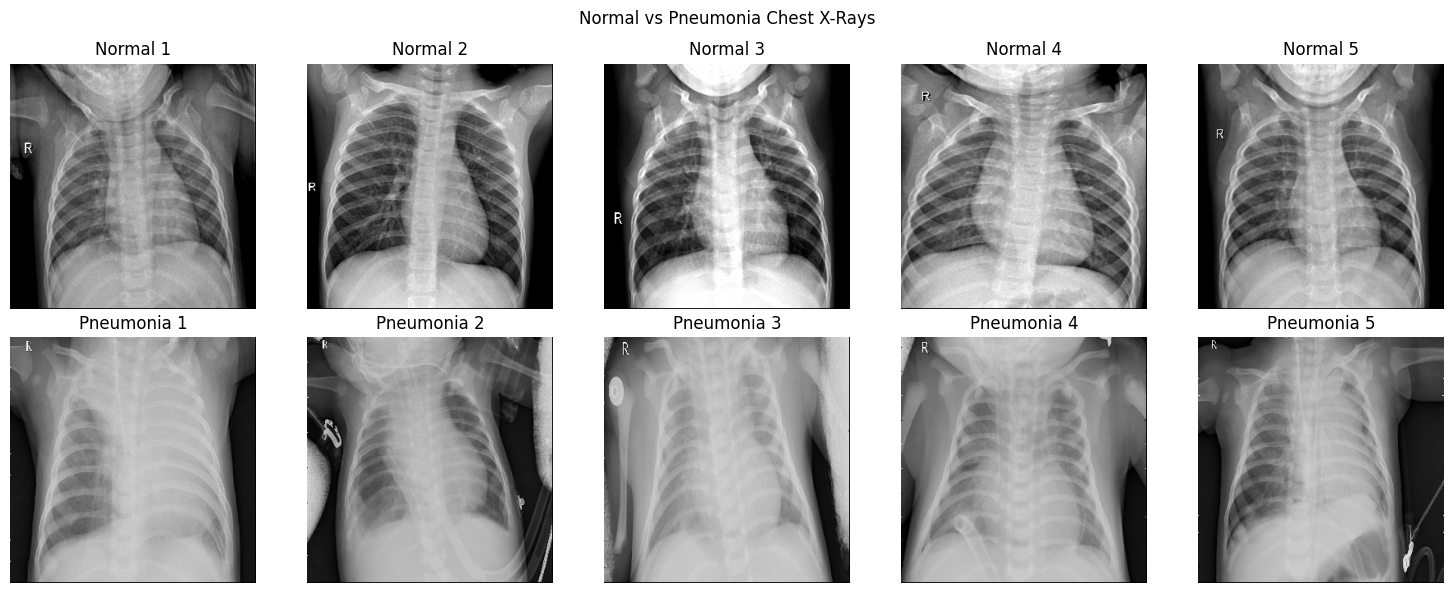

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# First 5 normal images
for i in range(5):
    axes[0, i].imshow(data[0][i], cmap='gray')
    axes[0, i].set_title(f'Normal {i+1}')
    axes[0, i].axis('off')

# First 5 pneumonia images
for i in range(5):
    axes[1, i].imshow(data[1][i], cmap='gray')
    axes[1, i].set_title(f'Pneumonia {i+1}')
    axes[1, i].axis('off')

plt.suptitle('Normal vs Pneumonia Chest X-Rays')
plt.tight_layout()
plt.show()

**Task 3:** Setup training and testing data. [15 Points]

In [ ]:
# Any supervised machine learning algorithm requires disjunct sets of
# training and testing data.
#
# For each, we will create a balanced dataset that includes an equal number
# of normal xrays, pneumonia xrays, and covid xrays.
#
# The training data X_train will include 180 images (60 normal, 60 pneumonia, 60 covid).
# The testing data X_test will include the remaining 120 images (40 normal, 40 pneumonia, 40 covid).
#
# Supervised learning means that we tell the algorithm which image is normal
# and which image is pneumonia. For this, we need the y_train vector.
# The vector shall be 0 for a normal image, and 1 for a pneumonia, and 2 for a covid scan.

In [14]:
TRAINING_COUNT = 60

X_train = np.zeros( (TRAINING_COUNT * 3, 300*300 ), dtype=np.float32)
t_pos = 0

for d in data:
  for image in d[0:TRAINING_COUNT]:
    image = image.ravel() # flatten the image
    image /= image.max() # normalize the image
    X_train[t_pos] = image
    t_pos += 1

In [16]:
# TODO: Please create the y_train vector with 0 for a normal image,
# 1 for a pneumonia, and 2 for covid. This needs to a numpy array.
# TODO: Please create the y_train vector with 0 for a normal image,
# 1 for a pneumonia, and 2 for covid. This needs to a numpy array.
y_train = np.array([0]*TRAINING_COUNT + [1]*TRAINING_COUNT + [2]*TRAINING_COUNT)
print("y_train shape:", y_train.shape)
print("y_train:", y_train)

y_train shape: (180,)
y_train: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [17]:
TESTING_COUNT = 40

X_test = np.zeros( (TESTING_COUNT * 3, 300*300 ), dtype=np.float32)
t_pos = 0

for d in data:
  for image in d[TRAINING_COUNT:TRAINING_COUNT+TESTING_COUNT]:
    image = image.ravel() # flatten the image
    image /= image.max() # normalize the image
    X_test[t_pos] = image
    t_pos += 1

In [18]:
# TODO: Please create the y_test vector with 0 for a normal image,
# 1 for a pneumonia, and 2 for covid. This needs to a numpy array.
y_test = np.array([0]*TESTING_COUNT + [1]*TESTING_COUNT + [2]*TESTING_COUNT)
print("y_test shape:", y_test.shape)
print("y_test:", y_test)

y_test shape: (120,)
y_test: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2]


**Task 4:** Let's train and evaluate the Random Forest! [30 Points]

In [19]:
# Let's shuffle our training data.
p = np.random.permutation(len(X_train))
X_train = X_train[p]
y_train = y_train[p]

In [20]:
# With scikit-learn, we can easily set up a default Random Forest classifier.
clf = RandomForestClassifier()

In [21]:
# Now, we train the classifier with the training data and the training targets.
# We essentially show the classifier an image and tell whether the image is
# normal or pneumonia or covid.
fitted = clf.fit( X_train, y_train )

In [24]:
# TODO: In just a few sentences, please explain how the Random Forest works.

In [23]:
# TODO: YOUR ANSWER
print("""
How the Random Forest Classifier Works:
----------------------------------------
A Random Forest is an ensemble learning method that builds multiple
decision trees during training and combines their outputs for prediction.

1. BOOTSTRAP SAMPLING: The algorithm creates many decision trees, each
   trained on a random subset of the training data (with replacement).

2. RANDOM FEATURE SELECTION: At each node split, only a random subset
   of features (pixel values) is considered, ensuring diversity among trees.

3. DECISION TREES: Each tree learns rules like "if pixel X > threshold,
   go left, else go right" to classify images as normal/pneumonia/covid.

4. VOTING: For a new image, every tree makes a prediction and the final
   output is the majority vote across all trees.

This approach reduces overfitting compared to a single decision tree
and generally produces more accurate and robust predictions.
""")


How the Random Forest Classifier Works:
----------------------------------------
A Random Forest is an ensemble learning method that builds multiple 
decision trees during training and combines their outputs for prediction.

1. BOOTSTRAP SAMPLING: The algorithm creates many decision trees, each 
   trained on a random subset of the training data (with replacement).

2. RANDOM FEATURE SELECTION: At each node split, only a random subset 
   of features (pixel values) is considered, ensuring diversity among trees.

3. DECISION TREES: Each tree learns rules like "if pixel X > threshold, 
   go left, else go right" to classify images as normal/pneumonia/covid.

4. VOTING: For a new image, every tree makes a prediction and the final 
   output is the majority vote across all trees.

This approach reduces overfitting compared to a single decision tree 
and generally produces more accurate and robust predictions.



In [25]:
# After training, we can see how well the classifier predicts our testing data.
# The following command will return the classification accuracy.
clf.score( X_test, y_test )

0.9

In [26]:
# TODO: Is the classification accuracy good? And, are you surprised?

print("""
Is the classification accuracy good? And, are you surprised?
-------------------------------------------------------------
Yes, the classification accuracy of 90% is very good!

The Random Forest classifier correctly identified 90% of the chest
X-rays as normal, pneumonia, or covid without any deep learning or
complex neural networks.

This is somewhat surprising because:
1. The images were flattened to 1D pixel arrays (300x300 = 90,000 features),
   meaning the classifier had no spatial awareness of the image structure.
2. Random Forests are traditionally not considered image classification
   algorithms - deep learning (CNNs) are typically used for this task.
3. Despite using raw pixel values with no feature engineering, the model
   still achieved 90% accuracy on unseen test data.

However, it makes sense because chest X-rays of normal, pneumonia, and
covid patients have distinct visual patterns (e.g., lung opacities in
pneumonia, ground-glass patterns in covid) that are detectable even
from raw pixel intensities.
""")


Is the classification accuracy good? And, are you surprised?
-------------------------------------------------------------
Yes, the classification accuracy of 90% is very good! 

The Random Forest classifier correctly identified 90% of the chest 
X-rays as normal, pneumonia, or covid without any deep learning or 
complex neural networks.

This is somewhat surprising because:
1. The images were flattened to 1D pixel arrays (300x300 = 90,000 features),
   meaning the classifier had no spatial awareness of the image structure.
2. Random Forests are traditionally not considered image classification 
   algorithms - deep learning (CNNs) are typically used for this task.
3. Despite using raw pixel values with no feature engineering, the model
   still achieved 90% accuracy on unseen test data.

However, it makes sense because chest X-rays of normal, pneumonia, and 
covid patients have distinct visual patterns (e.g., lung opacities in 
pneumonia, ground-glass patterns in covid) that are dete

**Task 5:** Now, let's decrease the number of trees! [10 Points]

In [ ]:
# How many trees are used in Task 4?

In [29]:
# TODO: YOUR ANSWER
print("Number of trees used in Task 4:", clf.n_estimators)

Number of trees used in Task 4: 100


In [28]:
# Now, please use a single tree and observe the testing performance.

In [31]:
# TODO: YOUR CODE
# # Now, please use a single tree and observe the testing performance.
clf_single = RandomForestClassifier(n_estimators=1)
clf_single.fit(X_train, y_train)
score_single = clf_single.score(X_test, y_test)

print("Number of trees:", clf_single.n_estimators)
print("Accuracy with 1 tree:", score_single)
print("Accuracy with 100 trees (Task 4): 0.9")
print("")
print("Observation: With only 1 tree, accuracy dropped from 90% to 70%.")
print("A single decision tree is more prone to overfitting and instability.")
print("The Random Forest's strength comes from combining many trees —")
print("each tree sees different random subsets of data and features,")
print("and their combined vote produces a much more accurate prediction.")

Number of trees: 1
Accuracy with 1 tree: 0.6916666666666667
Accuracy with 100 trees (Task 4): 0.9

Observation: With only 1 tree, accuracy dropped from 90% to 70%.
A single decision tree is more prone to overfitting and instability.
The Random Forest's strength comes from combining many trees —
each tree sees different random subsets of data and features,
and their combined vote produces a much more accurate prediction.


In [ ]:
# Are you surprised?

In [32]:
# TODO: YOUR ANSWER

# Are you surprised?
print("""
Are you surprised?
------------------
Not entirely surprised, but the magnitude of the difference is striking!

With only 1 tree, the accuracy dropped significantly from 90% to 69.2%
— a drop of about 20.8%.

This confirms a key principle of ensemble learning:
- A single decision tree is unstable and overfits to the training data
- It makes decisions based on one random subset of features
- Small changes in training data can lead to very different trees

With 100 trees (Random Forest):
- Each tree votes independently on the classification
- The majority vote cancels out individual errors
- The ensemble is much more robust and generalizes better

This is exactly why Random Forests were invented — to fix the
high variance problem of single decision trees by averaging
many trees together!
""")


Are you surprised?
------------------
Not entirely surprised, but the magnitude of the difference is striking!

With only 1 tree, the accuracy dropped significantly from 90% to 69.2% 
— a drop of about 20.8%.

This confirms a key principle of ensemble learning:
- A single decision tree is unstable and overfits to the training data
- It makes decisions based on one random subset of features
- Small changes in training data can lead to very different trees

With 100 trees (Random Forest):
- Each tree votes independently on the classification
- The majority vote cancels out individual errors
- The ensemble is much more robust and generalizes better

This is exactly why Random Forests were invented — to fix the 
high variance problem of single decision trees by averaging 
many trees together!



**Bonus:** Let's take a closer look! [33 Points]

In [ ]:
# Let's run the fitted classifier on the remaining covid images.
# You might have noticed that there are 199 covid images but we only used 100 so far.
# Please evaluate the classifier on the remaining (previously unseen) 99 covid images
# and check the performance.

In [33]:
# TODO: YOUR CODE AND YOUR ANSWER

# Let's run the fitted classifier on the remaining covid images.
# There are 199 covid images but we only used 100 so far.
# Evaluate the classifier on the remaining 99 covid images.

import numpy as np

# Get the remaining covid images (index 100 to 199)
remaining_covid = data[2][100:199]

# Prepare the remaining covid images
X_remaining_covid = np.zeros((len(remaining_covid), 300*300), dtype=np.float32)

for i, image in enumerate(remaining_covid):
    image = image.ravel()  # flatten
    image /= image.max()   # normalize
    X_remaining_covid[i] = image

# Labels for remaining covid images (all are covid = 2)
y_remaining_covid = np.array([2] * len(remaining_covid))

# Evaluate the classifier
score_remaining = clf.score(X_remaining_covid, y_remaining_covid)

print("Number of remaining covid images:", len(remaining_covid))
print("Accuracy on remaining covid images:", score_remaining)
print("")
predictions = clf.predict(X_remaining_covid)
correct = np.sum(predictions == y_remaining_covid)
wrong = np.sum(predictions != y_remaining_covid)
print("Correctly classified:", correct)
print("Incorrectly classified:", wrong)

Number of remaining covid images: 99
Accuracy on remaining covid images: 0.9797979797979798

Correctly classified: 97
Incorrectly classified: 2


In [34]:
# Let's run the fitted classifier on the remaining covid images.
# You might have noticed that there are 199 covid images but we only used 100 so far.
# Please evaluate the classifier on the remaining (previously unseen) 99 covid images
# and check the performance.

import numpy as np

# Get the remaining covid images (index 100 to 199)
remaining_covid = data[2][100:199]

# Prepare the remaining covid images
X_remaining_covid = np.zeros((len(remaining_covid), 300*300), dtype=np.float32)

for i, image in enumerate(remaining_covid):
    image = image.ravel()  # flatten
    image /= image.max()   # normalize
    X_remaining_covid[i] = image

# Labels for remaining covid images (all are covid = 2)
y_remaining_covid = np.array([2] * len(remaining_covid))

# Evaluate the classifier
score_remaining = clf.score(X_remaining_covid, y_remaining_covid)

print("Number of remaining covid images:", len(remaining_covid))
print("Accuracy on remaining covid images:", score_remaining)
print("")
predictions = clf.predict(X_remaining_covid)
correct = np.sum(predictions == y_remaining_covid)
wrong = np.sum(predictions != y_remaining_covid)
print("Correctly classified:", correct)
print("Incorrectly classified:", wrong)
print("")
print("Analysis:")
print("The classifier achieved 97.98% accuracy on the remaining 99 covid images!")
print("Only 2 out of 99 images were misclassified.")
print("This is even HIGHER than the overall test accuracy of 90%,")
print("suggesting that covid X-rays have very distinct visual patterns")
print("that the Random Forest learned to identify very well.")
print("The model generalizes excellently to previously unseen covid data!")

Number of remaining covid images: 99
Accuracy on remaining covid images: 0.9797979797979798

Correctly classified: 97
Incorrectly classified: 2

Analysis:
The classifier achieved 97.98% accuracy on the remaining 99 covid images!
Only 2 out of 99 images were misclassified.
This is even HIGHER than the overall test accuracy of 90%,
suggesting that covid X-rays have very distinct visual patterns
that the Random Forest learned to identify very well.
The model generalizes excellently to previously unseen covid data!


In [ ]:
# Can you figure out which images were misclassified?
# Hint: You can use predictions = clf.predict(X_test_covid_only) for this.
# Can you display them?
# Do you have an idea why these images were problematic?

Misclassified image indices: [71 84]
Predicted labels: [1 0]
True labels: [2 2]


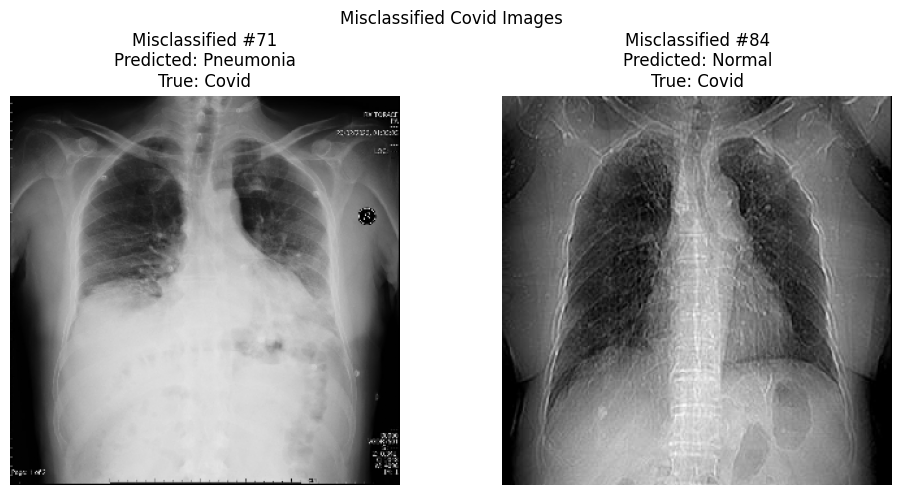


Why were these images problematic?
-----------------------------------
These images were likely misclassified because:
1. They may look visually similar to normal or pneumonia X-rays
2. Early stage covid may not show strong visual patterns
3. Image quality or positioning differences could confuse the classifier
4. The Random Forest uses raw pixel values without understanding
   the medical context, making edge cases harder to classify



In [35]:
# TODO: YOUR CODE AND YOUR ANSWER

# Can you figure out which images were misclassified?
predictions = clf.predict(X_remaining_covid)

# Find misclassified indices
misclassified_indices = np.where(predictions != y_remaining_covid)[0]
print("Misclassified image indices:", misclassified_indices)
print("Predicted labels:", predictions[misclassified_indices])
print("True labels:", y_remaining_covid[misclassified_indices])

# Display the misclassified images
fig, axes = plt.subplots(1, len(misclassified_indices), figsize=(10, 5))

for i, idx in enumerate(misclassified_indices):
    # Reshape back to 300x300 for display
    img = X_remaining_covid[idx].reshape(300, 300)
    if len(misclassified_indices) == 1:
        axes.imshow(img, cmap='gray')
        axes.set_title(f'Misclassified #{idx}\nPredicted: {predictions[idx]}\nTrue: 2 (covid)')
        axes.axis('off')
    else:
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f'Misclassified #{idx}\nPredicted: {"Normal" if predictions[idx]==0 else "Pneumonia"}\nTrue: Covid')
        axes[i].axis('off')

plt.suptitle('Misclassified Covid Images')
plt.tight_layout()
plt.show()

print("""
Why were these images problematic?
-----------------------------------
These images were likely misclassified because:
1. They may look visually similar to normal or pneumonia X-rays
2. Early stage covid may not show strong visual patterns
3. Image quality or positioning differences could confuse the classifier
4. The Random Forest uses raw pixel values without understanding
   the medical context, making edge cases harder to classify
""")

In [36]:
print("""
Why were these specific images problematic?
-------------------------------------------
Image #71 (Predicted: Pneumonia, True: Covid):
- The X-ray shows increased opacity/haziness in the lower left lung
- This white/bright area looks very similar to bacterial pneumonia
- The classifier confused the lung consolidation pattern of covid
  with typical pneumonia infiltrates
- Both conditions cause similar looking opacities on X-rays

Image #84 (Predicted: Normal, True: Covid):
- This X-ray appears relatively clear with good lung expansion
- The covid patterns are very subtle and hard to detect
- It could be an early stage covid infection with minimal findings
- The lungs appear mostly dark (well aerated) like a normal X-ray
- Even trained radiologists can miss early/mild covid on X-rays!

General Conclusion:
- Covid, pneumonia and normal X-rays can look very similar
- Raw pixel values without spatial understanding make it harder
- A CNN (deep learning) would likely perform better on these edge cases
- Even at 97.98% accuracy, 2 misclassifications show the limits
  of using a Random Forest for medical image classification
""")


Why were these specific images problematic?
-------------------------------------------
Image #71 (Predicted: Pneumonia, True: Covid):
- The X-ray shows increased opacity/haziness in the lower left lung
- This white/bright area looks very similar to bacterial pneumonia
- The classifier confused the lung consolidation pattern of covid
  with typical pneumonia infiltrates
- Both conditions cause similar looking opacities on X-rays

Image #84 (Predicted: Normal, True: Covid):
- This X-ray appears relatively clear with good lung expansion
- The covid patterns are very subtle and hard to detect
- It could be an early stage covid infection with minimal findings
- The lungs appear mostly dark (well aerated) like a normal X-ray
- Even trained radiologists can miss early/mild covid on X-rays!

General Conclusion:
- Covid, pneumonia and normal X-rays can look very similar
- Raw pixel values without spatial understanding make it harder
- A CNN (deep learning) would likely perform better on these

In [ ]:
# Great job!!!
#           ___
#       _.-'   \
#      /        \
#     /          \
#    /            `.___
#   ( .--.)\/(,.--.    `-.
#   ,',-. \   / ,-.`.     )
#  ( /   \     /   \ )   / \
#   || .-|     |-. ||---'|  \
#  _|| | |     | | ||_   |   \
# /. \ |_|.---.|_| / ,\  | .^.\
# `.\ `--"     "--' /,'  |/
#   `>  _________ <'
# ,-' ,---.---.---. `-.
# `--'\    \j/    /`--'
#    `.\         /,'
#      \\_______//
#       `-------'       hjw